In [1]:
# =========================
# Phase 1.4 - ResNet50 Transfer Learning
# Setup and Paths
# =========================

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import gc

# =========================
# Clear Runtime Memory Only
# =========================

tf.keras.backend.clear_session()
gc.collect()

# =========================
# Reproducibility
# =========================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =========================
# Project Paths
# =========================

PROJECT_DIR = Path("/content/drive/MyDrive/Calorify")
PHASE1_DIR = PROJECT_DIR / "phase1_clean"

SPLIT_DATA_DIR = PHASE1_DIR / "data" / "split"
METADATA_DIR = PHASE1_DIR / "metadata"
RESULTS_DIR = PHASE1_DIR / "results"
MODELS_DIR = PHASE1_DIR / "models"

train_dir = SPLIT_DATA_DIR / "train"
val_dir = SPLIT_DATA_DIR / "val"
test_dir = SPLIT_DATA_DIR / "test"

# ResNet50 specific outputs
RESNET_MODEL_PATH = MODELS_DIR / "resnet50_transfer_learning.keras"
RESNET_WEIGHTS_PATH = MODELS_DIR / "resnet50_transfer_learning.weights.h5"
RESNET_HISTORY_PATH = RESULTS_DIR / "resnet50_history.csv"

# =========================
# Load Class Names
# =========================

class_names_path = METADATA_DIR / "class_names.json"

with open(class_names_path, "r") as f:
    class_names = json.load(f)

NUM_CLASSES = len(class_names)

print("Project directory:", PROJECT_DIR)
print("Phase 1 directory:", PHASE1_DIR)
print("Split data directory:", SPLIT_DATA_DIR)
print("Train directory:", train_dir)
print("Val directory:", val_dir)
print("Test directory:", test_dir)

print("\nClass names:")
print(class_names)

print("\nNumber of classes:", NUM_CLASSES)
print("\nResNet50 model will be saved to:")
print(RESNET_MODEL_PATH)
print("\nResNet50 weights will be saved to:")
print(RESNET_WEIGHTS_PATH)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/Calorify
Phase 1 directory: /content/drive/MyDrive/Calorify/phase1_clean
Split data directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split
Train directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/train
Val directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/val
Test directory: /content/drive/MyDrive/Calorify/phase1_clean/data/split/test

Class names:
['burger', 'pizza', 'fries', 'pasta', 'rice', 'chicken', 'salad', 'sandwich', 'sushi', 'steak']

Number of classes: 10

ResNet50 model will be saved to:
/content/drive/MyDrive/Calorify/phase1_clean/models/resnet50_transfer_learning.keras

ResNet50 weights will be saved to:
/content/drive/MyDrive/Calorify/phase1_clean/models/resnet50_transfer_learning.weights.h5


In [2]:
# =========================
# Cell 2 - Load TensorFlow Datasets + Class Weights
# =========================

import tensorflow as tf
import pandas as pd

# =========================
# Dataset Config
# =========================

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# =========================
# Load Prepared Train / Val / Test Split
# =========================

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# =========================
# Prefetch for Performance
# =========================

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("\nDatasets loaded successfully.")

# =========================
# Load Class Weights
# =========================

class_weights_path = METADATA_DIR / "class_weights.csv"
class_weight_df = pd.read_csv(class_weights_path)

class_weight = {
    int(row["class_index"]): float(row["class_weight"])
    for _, row in class_weight_df.iterrows()
}

print("\nClass weights loaded from:")
print(class_weights_path)

display(class_weight_df)

print("\nclass_weight dictionary:")
print(class_weight)

Found 3413 files belonging to 10 classes.
Found 731 files belonging to 10 classes.
Found 732 files belonging to 10 classes.

Datasets loaded successfully.

Class weights loaded from:
/content/drive/MyDrive/Calorify/phase1_clean/metadata/class_weights.csv


,class_index,class_name,train_count,class_weight
0,0,burger,350,0.975143
1,1,pizza,350,0.975143
2,2,fries,350,0.975143
3,3,pasta,350,0.975143
4,4,rice,301,1.133887
5,5,chicken,350,0.975143
6,6,salad,350,0.975143
7,7,sandwich,350,0.975143
8,8,sushi,312,1.093910
9,9,steak,350,0.975143



class_weight dictionary:
{0: 0.9751428571428572, 1: 0.9751428571428572, 2: 0.9751428571428572, 3: 0.9751428571428572, 4: 1.1338870431893688, 5: 0.9751428571428572, 6: 0.9751428571428572, 7: 0.9751428571428572, 8: 1.0939102564102563, 9: 0.9751428571428572}


Data augmentation layer created successfully.


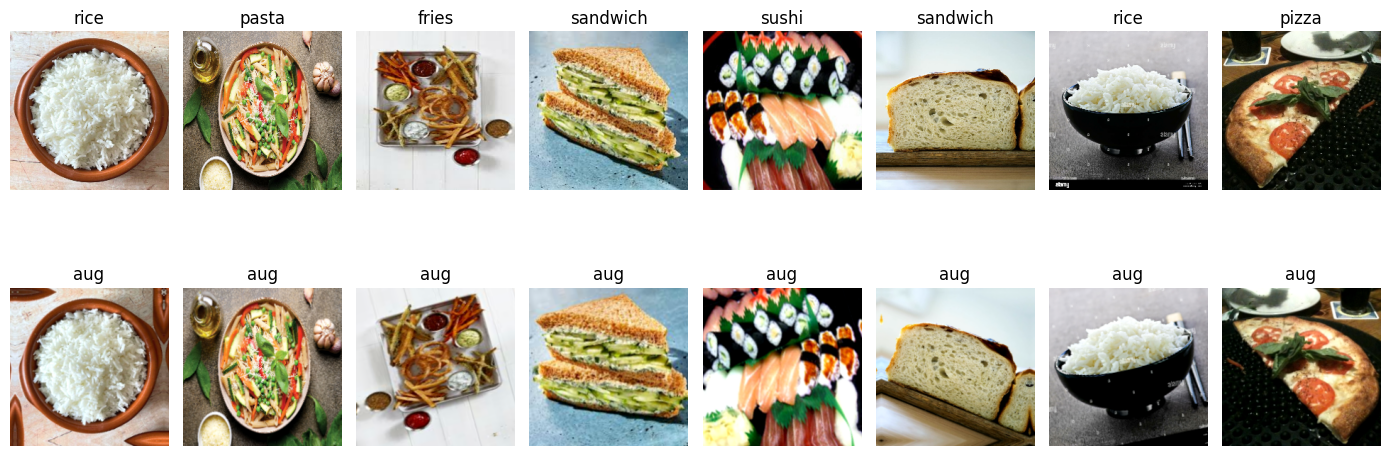

Sample image batch shape: (8, 224, 224, 3)
Sample label batch shape: (8, 10)


In [3]:
# =========================
# Cell 3 - Data Augmentation Preview for ResNet50
# =========================

import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Data Augmentation Layer
# =========================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="resnet50_data_augmentation")

print("Data augmentation layer created successfully.")

# =========================
# Preview Original vs Augmented Images
# =========================

for images, labels in train_ds.take(1):
    sample_images = images[:8]
    sample_labels = labels[:8]
    augmented_images = data_augmentation(sample_images, training=True)

plt.figure(figsize=(14, 6))

for i in range(8):
    label_index = np.argmax(sample_labels[i].numpy())
    label_name = class_names[label_index]

    # Original image
    ax = plt.subplot(2, 8, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(label_name)
    plt.axis("off")

    # Augmented image
    ax = plt.subplot(2, 8, i + 9)
    aug_img = augmented_images[i].numpy()
    aug_img = np.clip(aug_img, 0, 255).astype("uint8")
    plt.imshow(aug_img)
    plt.title("aug")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Sample image batch shape:", sample_images.shape)
print("Sample label batch shape:", sample_labels.shape)

In [4]:
# =========================
# Cell 4 - Build ResNet50 Transfer Learning Model
# =========================

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# =========================
# Custom Preprocessing Layer
# =========================

class ResNetPreprocessLayer(layers.Layer):
    def call(self, inputs):
        return preprocess_input(inputs)

# =========================
# ResNet50 Config
# =========================

IMAGE_SHAPE = (224, 224, 3)
LEARNING_RATE_RESNET = 1e-3
EPOCHS_RESNET = 15

print("Building ResNet50 transfer learning model...")
print("Number of classes:", NUM_CLASSES)

# =========================
# Load Pretrained Base Model
# =========================

base_model = ResNet50(
    input_shape=IMAGE_SHAPE,
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained base model first
base_model.trainable = False

print("ResNet50 base model loaded with ImageNet weights.")
print("Base model trainable:", base_model.trainable)

# =========================
# Build Full Model
# =========================

inputs = layers.Input(shape=IMAGE_SHAPE, name="input_image")

# Data augmentation only active during training
x = data_augmentation(inputs)

# ResNet50-specific preprocessing
x = ResNetPreprocessLayer(name="resnet50_preprocessing")(x)

# ResNet50 feature extractor
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.BatchNormalization(name="head_batch_norm")(x)
x = layers.Dropout(0.4, name="head_dropout")(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="food_class_output"
)(x)

resnet_model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="ResNet50_TransferLearning"
)

# =========================
# Compile Model
# =========================

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_RESNET),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

Building ResNet50 transfer learning model...
Number of classes: 10
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ResNet50 base model loaded with ImageNet weights.
Base model trainable: False


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_data_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50_preprocessing          │ (None, 224, 224, 3)    │             0 │
│ (ResNetPreprocessLayer)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_batch_norm                 │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ head_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ food_class_output (Dense)       │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,115,850 (91.99 MB)

 Trainable params: 527,626 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

In [5]:
# =========================
# Cell 5 - Train ResNet50 Frozen Base
# =========================

import pandas as pd
import tensorflow as tf

# =========================
# ResNet50 Callbacks
# =========================

resnet_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(RESNET_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

# =========================
# Train ResNet50 Head
# =========================

resnet_history = resnet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_RESNET,
    callbacks=resnet_callbacks,
    class_weight=class_weight
)

# =========================
# Save Training History
# =========================

resnet_history_df = pd.DataFrame(resnet_history.history)
resnet_history_df.to_csv(RESNET_HISTORY_PATH, index=False)

print("ResNet50 frozen-base training completed.")
print("ResNet50 model saved to:")
print(RESNET_MODEL_PATH)

print("\nResNet50 history saved to:")
print(RESNET_HISTORY_PATH)

display(resnet_history_df)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5868 - loss: 1.3751
Epoch 1: val_loss improved from None to 0.65238, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/resnet50_transfer_learning.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/resnet50_transfer_learning.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 784s 7s/step - accuracy: 0.7006 - loss: 0.9632 - val_accuracy: 0.8016 - val_loss: 0.6524 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8336 - loss: 0.5151
Epoch 2: val_loss improved from 0.65238 to 0.54481, saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/resnet50_transfer_learning.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Calorify/phase1_clean/models/resnet50_transfer_learning.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 753s 7s/step - accuracy: 0.8359 - loss: 0.5028 - val_accuracy: 0.8427 - val_loss: 0.5448 - learning_rate: 0.0010
Epo

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.700557,0.963199,0.801642,0.652381,0.00100
1,0.835921,0.502814,0.842681,0.544811,0.00100
2,0.871960,0.400020,0.826265,0.612152,0.00100
3,0.882801,0.351788,0.842681,0.542450,0.00100
4,0.898330,0.308267,0.852257,0.562343,0.00100
5,0.916203,0.263787,0.861833,0.535763,0.00100
6,0.920305,0.237545,0.856361,0.577193,0.00100
7,0.932904,0.198738,0.865937,0.559560,0.00100
8,0.951069,0.159185,0.870041,0.494332,0.00050
9,0.958101,0.133764,0.865937,0.531086,0.00050


In [6]:
# =========================
# Cell 6 - Evaluate ResNet50 on Test Set
# =========================

test_loss, test_accuracy = resnet_model.evaluate(test_ds)

print("ResNet50 Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 144s 6s/step - accuracy: 0.8634 - loss: 0.4714
ResNet50 Test Results
Test Loss: 0.4714
Test Accuracy: 0.8634


In [7]:
# =========================
# Save ResNet50 Weights Safely
# =========================

resnet_model.save_weights(RESNET_WEIGHTS_PATH)

print("ResNet50 weights saved safely to:")
print(RESNET_WEIGHTS_PATH)

ResNet50 weights saved safely to:
/content/drive/MyDrive/Calorify/phase1_clean/models/resnet50_transfer_learning.weights.h5


ResNet50 training history loaded from:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.700557,0.963199,0.801642,0.652381,0.00100
1,0.835921,0.502814,0.842681,0.544811,0.00100
2,0.871960,0.400020,0.826265,0.612152,0.00100
3,0.882801,0.351788,0.842681,0.542450,0.00100
4,0.898330,0.308267,0.852257,0.562343,0.00100
5,0.916203,0.263787,0.861833,0.535763,0.00100
6,0.920305,0.237545,0.856361,0.577193,0.00100
7,0.932904,0.198738,0.865937,0.559560,0.00100
8,0.951069,0.159185,0.870041,0.494332,0.00050
9,0.958101,0.133764,0.865937,0.531086,0.00050


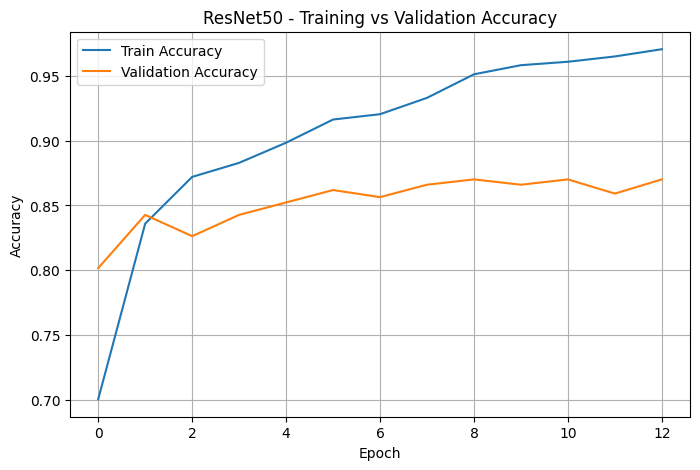

Accuracy curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_accuracy_curve.png


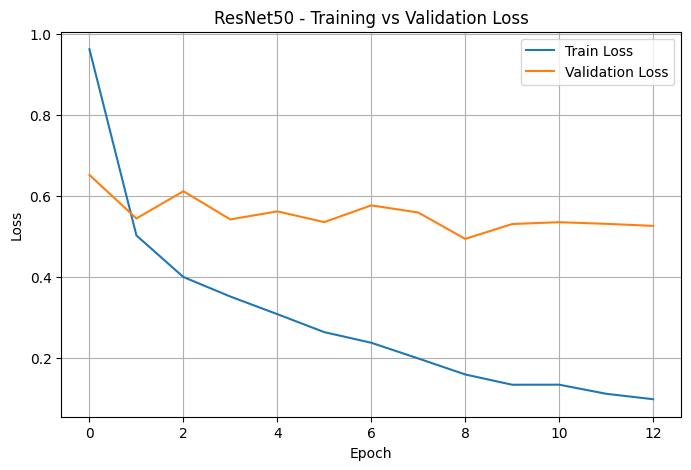

Loss curve saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_loss_curve.png


In [8]:
# =========================
# Cell 7 - ResNet50 Training Curves
# =========================

import pandas as pd
import matplotlib.pyplot as plt

# Load ResNet50 history
resnet_history_df = pd.read_csv(RESNET_HISTORY_PATH)

print("ResNet50 training history loaded from:")
print(RESNET_HISTORY_PATH)

display(resnet_history_df)

# =========================
# Accuracy Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(resnet_history_df["accuracy"], label="Train Accuracy")
plt.plot(resnet_history_df["val_accuracy"], label="Validation Accuracy")
plt.title("ResNet50 - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

resnet_accuracy_curve_path = RESULTS_DIR / "resnet50_accuracy_curve.png"
plt.savefig(resnet_accuracy_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Accuracy curve saved to:")
print(resnet_accuracy_curve_path)

# =========================
# Loss Curve
# =========================

plt.figure(figsize=(8, 5))
plt.plot(resnet_history_df["loss"], label="Train Loss")
plt.plot(resnet_history_df["val_loss"], label="Validation Loss")
plt.title("ResNet50 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

resnet_loss_curve_path = RESULTS_DIR / "resnet50_loss_curve.png"
plt.savefig(resnet_loss_curve_path, dpi=300, bbox_inches="tight")
plt.show()

print("Loss curve saved to:")
print(resnet_loss_curve_path)

Using ResNet50 model currently in memory with best restored weights.
ResNet50 classification report saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_classification_report.csv


,precision,recall,f1-score,support
burger,0.881579,0.893333,0.887417,75.000000
pizza,0.921053,0.933333,0.927152,75.000000
fries,0.916667,0.880000,0.897959,75.000000
pasta,0.833333,0.800000,0.816327,75.000000
rice,0.931034,0.830769,0.878049,65.000000
chicken,0.805195,0.826667,0.815789,75.000000
salad,0.900000,0.960000,0.929032,75.000000
sandwich,0.843750,0.720000,0.776978,75.000000
sushi,0.792208,0.910448,0.847222,67.000000
steak,0.825000,0.880000,0.851613,75.000000


ResNet50 confusion matrix CSV saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_confusion_matrix.csv


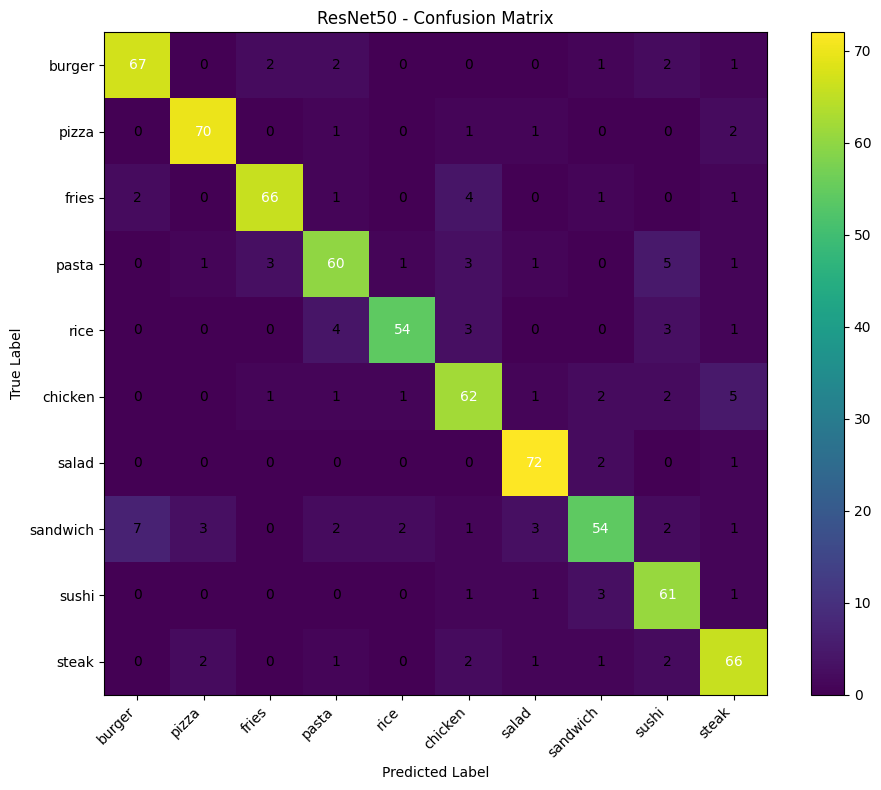

ResNet50 confusion matrix image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_confusion_matrix.png


In [9]:
# =========================
# Cell 8 - ResNet50 Classification Report + Confusion Matrix
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

# Use current ResNet50 model in memory
# It restored best weights using EarlyStopping
best_resnet_model = resnet_model

print("Using ResNet50 model currently in memory with best restored weights.")

# =========================
# Collect True Labels and Predictions
# =========================

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probabilities = best_resnet_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)

    y_true.extend(true_indices)
    y_pred.extend(pred_indices)
    y_prob.extend(np.max(probabilities, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# =========================
# Classification Report
# =========================

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

resnet_report_df = pd.DataFrame(report_dict).transpose()

resnet_report_path = RESULTS_DIR / "resnet50_classification_report.csv"
resnet_report_df.to_csv(resnet_report_path)

print("ResNet50 classification report saved to:")
print(resnet_report_path)

display(resnet_report_df)

# =========================
# Confusion Matrix
# =========================

cm = confusion_matrix(y_true, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=class_names,
    columns=class_names
)

resnet_cm_csv_path = RESULTS_DIR / "resnet50_confusion_matrix.csv"
cm_df.to_csv(resnet_cm_csv_path)

print("ResNet50 confusion matrix CSV saved to:")
print(resnet_cm_csv_path)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("ResNet50 - Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            format(cm[i, j], "d"),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()

resnet_cm_png_path = RESULTS_DIR / "resnet50_confusion_matrix.png"
plt.savefig(resnet_cm_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("ResNet50 confusion matrix image saved to:")
print(resnet_cm_png_path)

ResNet50 wrong predictions saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_wrong_predictions.csv

Number of wrong predictions: 100
Number of correct predictions: 632


,image_path,true_class,predicted_class,confidence,is_correct
0,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.501493,False
1,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,pasta,0.273553,False
2,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sushi,0.793975,False
3,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,fries,0.393068,False
4,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,fries,0.456034,False
5,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,pasta,0.864825,False
6,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,steak,0.478638,False
7,/content/drive/MyDrive/Calorify/phase1_clean/d...,burger,sandwich,0.619109,False
8,/content/drive/MyDrive/Calorify/phase1_clean/d...,pizza,chicken,0.995140,False
9,/content/drive/MyDrive/Calorify/phase1_clean/d...,pizza,steak,0.700852,False


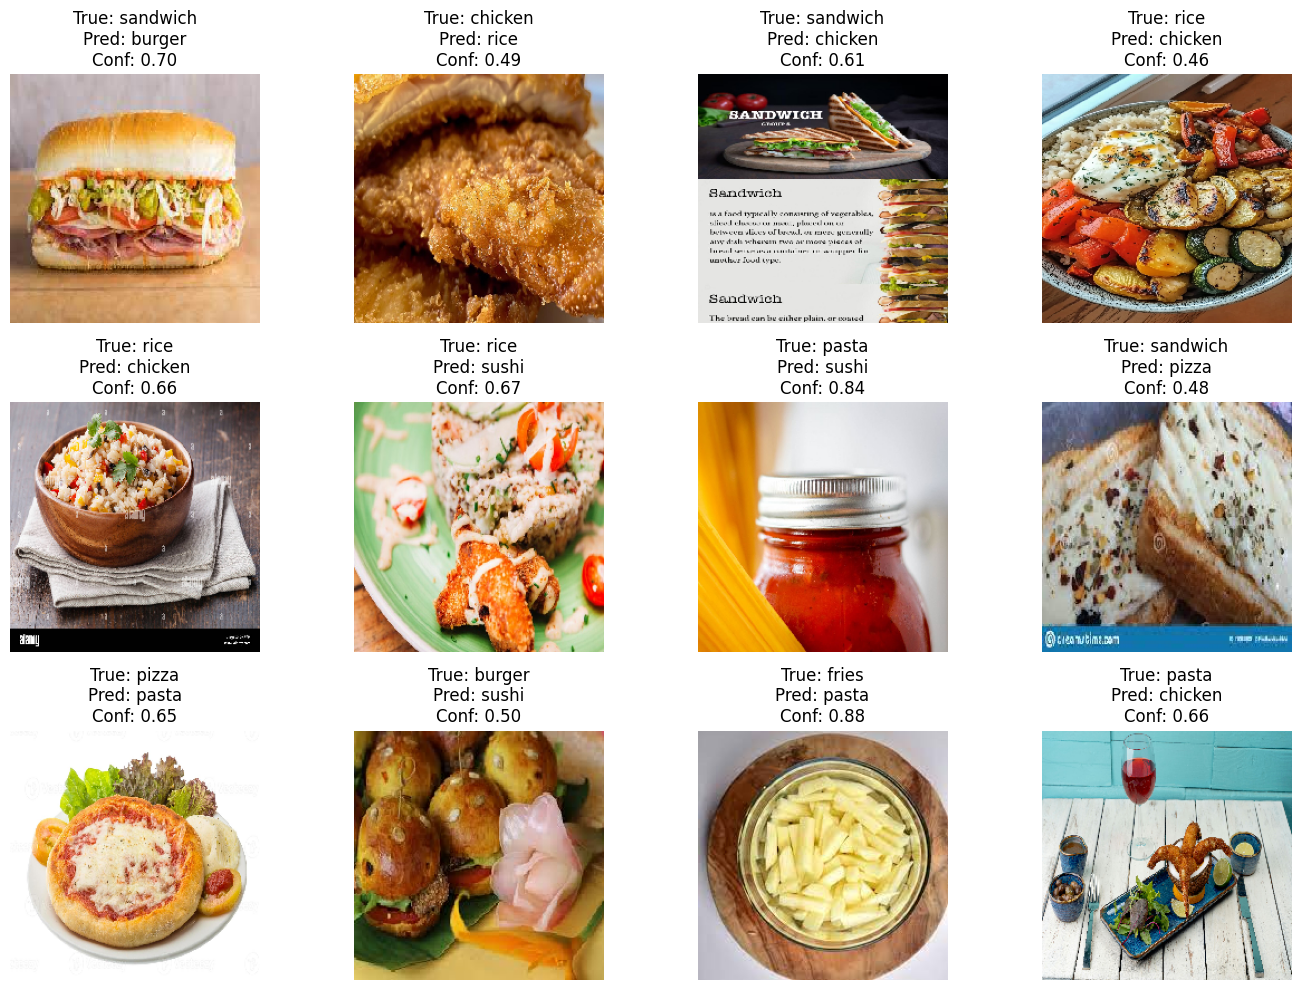

ResNet50 wrong prediction samples image saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_wrong_prediction_samples.png


In [10]:
# =========================
# Cell 9 - ResNet50 Wrong Prediction Samples
# =========================

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use current ResNet50 model in memory
best_resnet_model = resnet_model

wrong_records = []
correct_records = []

# Collect file paths from test directory in the same order as test_ds
test_image_paths = []

for class_name in class_names:
    class_dir = test_dir / class_name
    class_files = sorted([
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in [".jpg", ".jpeg", ".png", ".webp"]
    ])
    test_image_paths.extend(class_files)

sample_index = 0

for images, labels in test_ds:
    probabilities = best_resnet_model.predict(images, verbose=0)

    true_indices = np.argmax(labels.numpy(), axis=1)
    pred_indices = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    for i in range(len(images)):
        true_class = class_names[true_indices[i]]
        predicted_class = class_names[pred_indices[i]]
        confidence = float(confidences[i])

        image_path = str(test_image_paths[sample_index]) if sample_index < len(test_image_paths) else ""

        record = {
            "image_path": image_path,
            "true_class": true_class,
            "predicted_class": predicted_class,
            "confidence": confidence,
            "is_correct": true_class == predicted_class
        }

        if true_class == predicted_class:
            correct_records.append(record)
        else:
            wrong_records.append(record)

        sample_index += 1

resnet_wrong_df = pd.DataFrame(wrong_records)
resnet_correct_df = pd.DataFrame(correct_records)

resnet_wrong_predictions_path = RESULTS_DIR / "resnet50_wrong_predictions.csv"
resnet_wrong_df.to_csv(resnet_wrong_predictions_path, index=False)

print("ResNet50 wrong predictions saved to:")
print(resnet_wrong_predictions_path)

print("\nNumber of wrong predictions:", len(resnet_wrong_df))
print("Number of correct predictions:", len(resnet_correct_df))

display(resnet_wrong_df.head(20))

# =========================
# Show Sample Wrong Predictions
# =========================

sample_wrong_df = resnet_wrong_df.sample(
    n=min(12, len(resnet_wrong_df)),
    random_state=42
).reset_index(drop=True)

plt.figure(figsize=(14, 10))

for i, row in sample_wrong_df.iterrows():
    img_path = row["image_path"]

    img = tf.keras.utils.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img).astype("uint8")

    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(img_array)
    plt.title(
        f"True: {row['true_class']}\nPred: {row['predicted_class']}\nConf: {row['confidence']:.2f}"
    )
    plt.axis("off")

plt.tight_layout()

resnet_wrong_samples_path = RESULTS_DIR / "resnet50_wrong_prediction_samples.png"
plt.savefig(resnet_wrong_samples_path, dpi=300, bbox_inches="tight")
plt.show()

print("ResNet50 wrong prediction samples image saved to:")
print(resnet_wrong_samples_path)

In [11]:
# =========================
# Cell 10 - Save ResNet50 Final Summary
# =========================

import pandas as pd

resnet_summary = {
    "model_name": "ResNet50 Transfer Learning",
    "model_type": "Pretrained CNN / Residual Network",
    "training_strategy": "Frozen ResNet50 base + custom classification head",
    "weights_file": str(RESNET_WEIGHTS_PATH),
    "history_file": str(RESNET_HISTORY_PATH),

    # Test results
    "test_accuracy": 0.8634,
    "test_loss": 0.4714,

    # Validation results
    "best_validation_accuracy": 0.870041,
    "best_validation_loss": 0.494332,
    "best_val_loss_epoch": 9,

    # Classification report
    "macro_f1_score": 0.862754,
    "weighted_f1_score": 0.862715,

    # Error analysis
    "correct_predictions": 632,
    "wrong_predictions": 100,

    "status": "Completed",
    "notes": (
        "ResNet50 achieved strong performance and improved over the Custom CNN baseline. "
        "It also slightly outperformed MobileNetV2 in test accuracy, but remained below EfficientNetB0. "
        "The training curves showed moderate overfitting, with training accuracy increasing up to around 97% "
        "while validation accuracy plateaued around 86-87%. EarlyStopping and ModelCheckpoint were used to "
        "restore the best validation-loss checkpoint. ResNet50 was kept as an important residual-network "
        "comparison model, while EfficientNetB0 remained the best-performing visual classifier so far. "
        "Most remaining errors occurred between visually similar or noisy classes such as sandwich/burger, "
        "rice/chicken, fries/pasta, pasta/sushi, and pizza/pasta."
    )
}

resnet_summary_df = pd.DataFrame([resnet_summary])

resnet_summary_csv_path = RESULTS_DIR / "resnet50_final_summary.csv"
resnet_summary_txt_path = RESULTS_DIR / "resnet50_final_summary.txt"

resnet_summary_df.to_csv(resnet_summary_csv_path, index=False)

with open(resnet_summary_txt_path, "w", encoding="utf-8") as f:
    for key, value in resnet_summary.items():
        f.write(f"{key}: {value}\n")

print("ResNet50 final summary saved to:")
print(resnet_summary_csv_path)
print(resnet_summary_txt_path)

display(resnet_summary_df)

ResNet50 final summary saved to:
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_final_summary.csv
/content/drive/MyDrive/Calorify/phase1_clean/results/resnet50_final_summary.txt


,model_name,model_type,training_strategy,weights_file,history_file,test_accuracy,test_loss,best_validation_accuracy,best_validation_loss,best_val_loss_epoch,macro_f1_score,weighted_f1_score,correct_predictions,wrong_predictions,status,notes
0,ResNet50 Transfer Learning,Pretrained CNN / Residual Network,Frozen ResNet50 base + custom classification head,/content/drive/MyDrive/Calorify/phase1_clean/m...,/content/drive/MyDrive/Calorify/phase1_clean/r...,0.8634,0.4714,0.870041,0.494332,9,0.862754,0.862715,632,100,Completed,ResNet50 achieved strong performance and impro...


In [12]:
# Final Summary — ResNet50 Transfer Learning

#In this notebook, ResNet50 was used as the fourth Phase 1 image classification model after the Custom CNN baseline, MobileNetV2, and EfficientNetB0. The same prepared train, validation, and test split was used to ensure fair comparison across all visual models.

#ResNet50 was loaded with pretrained ImageNet weights and used as a frozen residual feature extractor. A custom classification head was added on top of the pretrained base model for the 10 food classes.

#The model achieved:

#- Test Accuracy: 86.34%
#- Test Loss: 0.4714
#- Best Validation Accuracy: 87.00%
#- Best Validation Loss: 0.4943
#- Macro F1-score: 86.28%
#- Weighted F1-score: 86.27%
#- Correct Predictions: 632
#- Wrong Predictions: 100

#ResNet50 achieved strong performance and improved significantly over the Custom CNN baseline. It also slightly outperformed MobileNetV2 in test accuracy, but remained below EfficientNetB0.

#The training curves showed moderate overfitting, with training accuracy increasing up to around 97% while validation accuracy plateaued around 86–87%. EarlyStopping and ModelCheckpoint were used to restore the best validation-loss checkpoint.

#The confusion matrix showed strong performance for classes such as salad, pizza, fries, burger, and rice. Remaining errors mainly occurred between visually similar or noisy classes such as sandwich/burger, rice/chicken, fries/pasta, pasta/sushi, and pizza/pasta.

#Overall, ResNet50 is an important residual-network comparison model, while EfficientNetB0 remains the best-performing visual classifier so far.